In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision

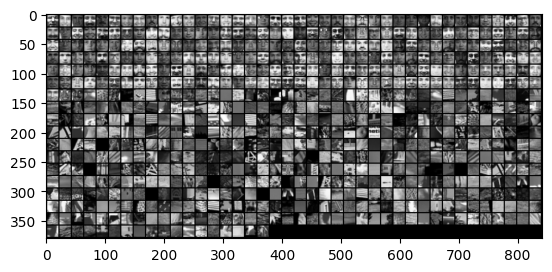

In [10]:
#########################################################################################################################
## Loading data
#########################################################################################################################


data = np.load('data/viola_jones.npz')
X=data['data_matrix']
Y=data['target']

X_torch=torch.from_numpy(X[0:6977:10,:,:]).unsqueeze(1)/255
tensor_grid=torchvision.utils.make_grid(X_torch,nrow=40)
image_grid=tensor_grid.permute(1,2,0)
plt.imshow(image_grid)
plt.show()

In [11]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

X_torch=torch.from_numpy(X).float().unsqueeze(1)/255
Y_torch=torch.from_numpy(Y).float()

# Splitting data into training and validation
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    X_torch,Y_torch,
    test_size=0.2, 
    random_state=42,
)

#Defining the Dataset 
class Char_Dataset(Dataset):
    def __init__(self,data,target,train:bool = True, transforms=None):
        self.data=data
        self.target=target
        self.train=train
        self.transforms=transforms
        
    def __getitem__(self,index):
        
        x=self.data[index,:,:]
        
        if(self.train):
            if(self.transforms):
                x=self.transforms(x)
                
        
        if(self.train):
            # During training, for each image the Dataset returns
            #  - an image x
            #  - the true class y:  
            y=self.target[index,]
            return x,y
        else:
            # During testing, only the image is returned
            return x
        
    def __len__(self):
        return len(self.target)
    
# Initializion datasets and dataloaders
batch_size = 500

train_dataset=Char_Dataset(
    data=Xtrain,
    target=Ytrain,
    train=True,
    transforms=None
)

valid_dataset=Char_Dataset(
    data=Xvalid,
    target=Yvalid,
    train=True,
    transforms=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

In [12]:
# Define the model
class CNN_model(nn.Module):
    def __init__(self):
        super(CNN_model, self).__init__()
        
        self.layer_1 = self._make_conv_block(1, 16)
        self.layer_2 = self._make_conv_block(16, 32)
        self.layer_3 = self._make_conv_block(32, 64)

        self.layer_4=nn.Flatten()
        self.layer_5=nn.Linear(256,2)
        
    def _make_conv_block(self, in_c, out_c):
        conv_layer = nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        )
        return conv_layer
    
    def forward(self,x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        xf = self.layer_4(x)
        #print(x.size())
        x = self.layer_5(xf)
        
        return x, xf

# Initialize the model
model=CNN_model()

In [13]:
x,y = next(iter(train_loader))
print(x.size())
out,xf=model(x)
_, preds = torch.max(out, 1)
torch.sum(preds == y)

#len(datasets['train'])

torch.Size([500, 1, 19, 19])


tensor(320)

In [14]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################
datasets={'train':train_dataset,'valid':valid_dataset}
dataloaders={'train':train_loader,'valid':valid_loader}
len(datasets['train'])

optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

# if GPU is available, use it, otherwise use CPU
device = torch.device("cpu")

########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

for epoch in range(num_epochs):
        
    for phase in ['train', 'valid']:
        running_loss = 0.0
        running_corrects = 0.0
        if phase == 'train':
            model.train()
        else:
            model.eval()

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels=labels.to(device)

            # Zero out the grads
            optimizer.zero_grad()

            # Forward
            # Track history in train mode
            with torch.set_grad_enabled(phase == 'train'):
                model=model.to(device)
                outputs, xf = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels.type(torch.LongTensor).to(device))

                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                
                # Statistics
                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds == labels)
        
        epoch_loss = running_loss/len(datasets[phase])
        epoch_acc = running_corrects.double()/len(datasets[phase])
        print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

train Loss: 0.6531 Acc: 0.6542
valid Loss: 0.6309 Acc: 0.6426
train Loss: 0.5966 Acc: 0.6798
valid Loss: 0.5354 Acc: 0.7636
train Loss: 0.4880 Acc: 0.7848
valid Loss: 0.3376 Acc: 0.8668
train Loss: 0.3030 Acc: 0.8722
valid Loss: 0.2304 Acc: 0.9047
train Loss: 0.2239 Acc: 0.9140
valid Loss: 0.1693 Acc: 0.9327
train Loss: 0.1705 Acc: 0.9398
valid Loss: 0.1321 Acc: 0.9542
train Loss: 0.1354 Acc: 0.9522
valid Loss: 0.1154 Acc: 0.9563
train Loss: 0.0973 Acc: 0.9676
valid Loss: 0.0856 Acc: 0.9713
train Loss: 0.0763 Acc: 0.9751
valid Loss: 0.0844 Acc: 0.9721
train Loss: 0.0627 Acc: 0.9805
valid Loss: 0.0631 Acc: 0.9814


In [15]:
######################################################################################################
## Using the network as feature extractor
######################################################################################################
Xtrain_feat=torch.tensor([])
Xvalid_feat=torch.tensor([])

for inputs, labels in dataloaders['train']:
    inputs = inputs.to(device)
    labels=labels.to(device)

    model=model.to(device)
    outputs, xf = model(inputs)
    
    Xtrain_feat = torch.cat((Xtrain_feat, xf))

for inputs, labels in dataloaders['valid']:
    inputs = inputs.to(device)
    labels=labels.to(device)

    model=model.to(device)
    outputs, xf = model(inputs)
    
    Xvalid_feat = torch.cat((Xvalid_feat, xf))

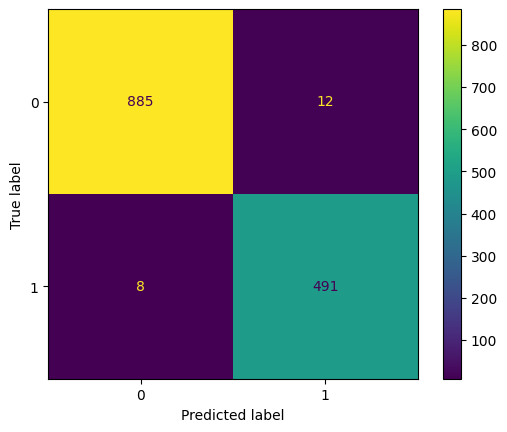

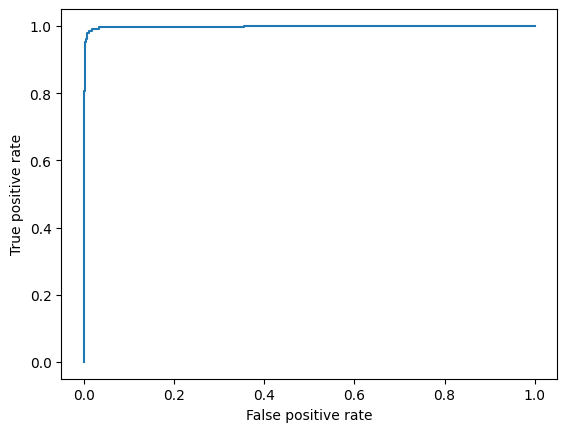

In [16]:
######################################################################################################
## Train a SVM classifier using CNN-extracted features
######################################################################################################

Xtrain_np=Xtrain_feat.detach().numpy()
Xtest_np=Xvalid_feat.detach().numpy()
Ytrain_np=Ytrain.numpy()
Ytest_np=Yvalid.numpy()

clf = SVC(C=1.0, kernel='rbf',gamma='scale', probability=True)
clf.fit(Xtrain_np,Ytrain_np)
p=clf.predict_proba(Xtest_np)

cm = confusion_matrix(Ytest_np, p[:,1]>0.5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

fpr, tpr, th = roc_curve(Ytest_np, p[:,1])
plt.plot(fpr,tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show()